## DỰ ĐOÁN TỶ LỆ TỘI PHẠM


In [8]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
#1. Load dataset đã làm sạch
load_dotenv(dotenv_path="../.env")

data_path = os.getenv("PROCESSED_DATA_PATH")

if data_path:
    print(f"Đang đọc dữ liệu từ đường dẫn cấu hình: {data_path}")
    df = pd.read_csv(data_path)

    print(f"Tải dữ liệu thành công! Kích thước dữ liệu: {df.shape}")
    display(df.head())
else:
    print("Lỗi: Không tìm thấy file")

Đang đọc dữ liệu từ đường dẫn cấu hình: ../data/processed/cleaned_crime_data.csv
Tải dữ liệu thành công! Kích thước dữ liệu: (2215, 123)


,communityname,State,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,pctHisp,pct12-21,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,1,11980,3.10,1.37,91.78,6.50,1.88,12.47,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,1,23123,2.82,0.80,95.57,3.44,0.85,11.01,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,1,29344,2.43,0.74,94.33,3.43,2.35,11.36,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,1,16656,2.40,1.70,97.35,0.50,0.70,12.55,...,225.0,1301.78,716.0,4142.56,47.0,271.93,5.0,21.08,306.64,4425.45
4,Bemidjicity,MN,1,11245,2.76,0.53,89.16,1.17,0.52,24.46,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,374.06,9988.79


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

TARGET = 'violentPerPop'
crime_cols = ['murders', 'murdPerPop', 'rapes', 'rapesPerPop', 'robberies', 'robbbPerPop',
              'assaults', 'assaultPerPop', 'burglaries', 'burglPerPop', 'larcenies', 'larcPerPop',
              'autoTheft', 'autoTheftPerPop', 'arsons', 'arsonsPerPop', 'nonViolPerPop']
df = df.drop(columns=[c for c in crime_cols if c in df.columns])

df = df.dropna(subset=[TARGET])

# 1. XÓA CÁC BIẾN ĐỊNH DANH (Non-predictive)
cols_to_drop = ['communityname', 'State', 'countyCode', 'communityCode', 'fold']

# Tách biến dự báo X:
X = df.drop(columns=['violentPerPop'] + [c for c in cols_to_drop if c in df.columns])

# Lọc thêm 1 lần nữa để đảm bảo chỉ còn dữ liệu dạng số
X = X.select_dtypes(include=[np.number])

y = df['violentPerPop']

# 2. Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Chạy mô hình
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({"Mô hình": name, "R2 Score": r2, "RMSE": rmse})

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("Kết quả đánh giá mô hình:")
display(results_df)

Kết quả đánh giá mô hình:


,Mô hình,R2 Score,RMSE
1,Random Forest,0.564832,362.426309
2,Gradient Boosting,0.553826,366.981166
0,Linear Regression,0.531758,375.947137


/var/folders/0p/ptrnc3g9273b920z_svkthm80000gn/T/ipykernel_2799/1241343821.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1], palette='magma')


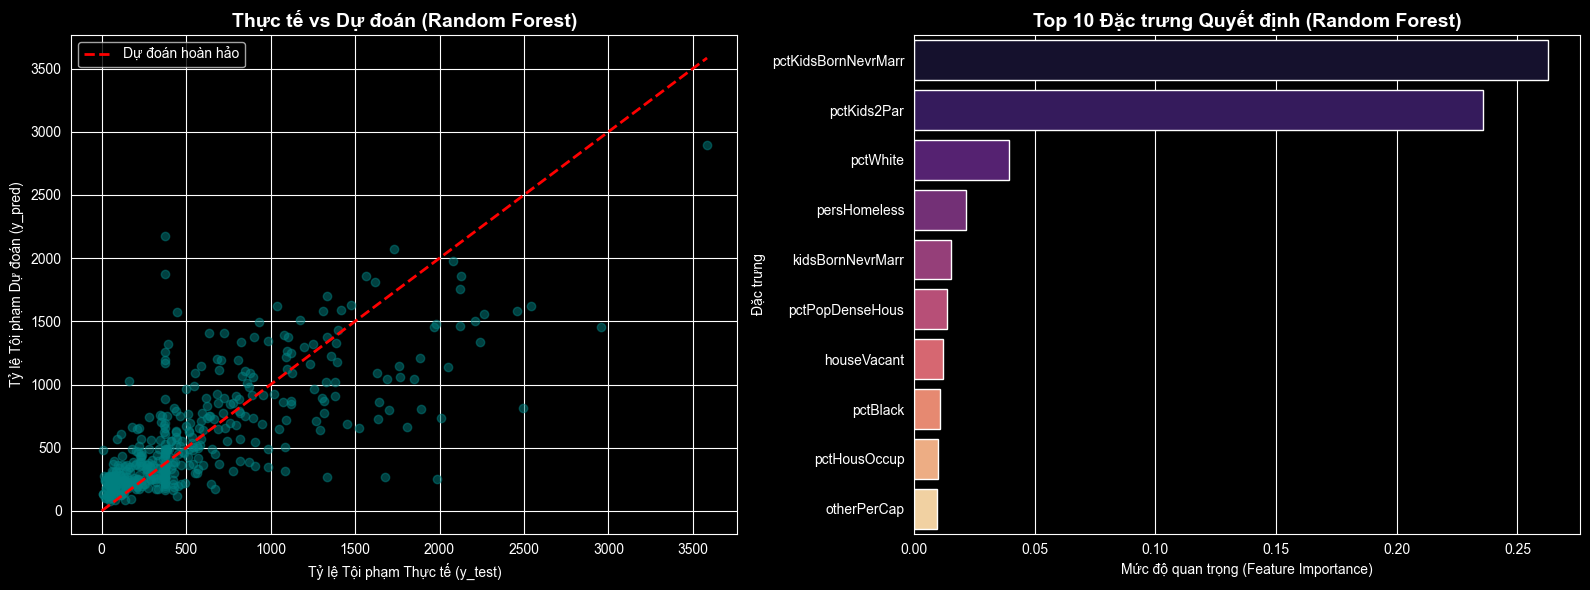

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trích xuất mô hình có kết quả tốt nhất từ bảng results_df
best_model_name = results_df.iloc[0]['Mô hình']
best_model = models[best_model_name]

# Dự đoán trên tập test với mô hình tốt nhất
y_pred_best = best_model.predict(X_test_scaled)
# Vì tỷ lệ tội phạm không thể âm, ta chặn giá trị dự đoán thấp nhất là 0
y_pred_best = np.clip(y_pred_best, 0, None)

# Thiết lập khung hình vẽ 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# BIỂU ĐỒ 1: THỰC TẾ VS. DỰ ĐOÁN
# ==========================================
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='teal')


max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Dự đoán hoàn hảo')

axes[0].set_title(f'Thực tế vs Dự đoán ({best_model_name})', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Tỷ lệ Tội phạm Thực tế (y_test)')
axes[0].set_ylabel('Tỷ lệ Tội phạm Dự đoán (y_pred)')
axes[0].legend()

# ==========================================
# BIỂU ĐỒ 2: TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT
# ==========================================
# Kiểm tra xem mô hình (Random Forest, Gradient Boosting) có hỗ trợ feature_importances_ không
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_10 = importances.sort_values(ascending=False).head(10)

    sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1], palette='magma')
    axes[1].set_title(f'Top 10 Đặc trưng Quyết định ({best_model_name})', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Mức độ quan trọng (Feature Importance)')

# Nếu mô hình tốt nhất là Linear Regression, ta sẽ dùng Hệ số (Coefficients)
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_, index=X.columns)
    top_10 = coefs.abs().sort_values(ascending=False).head(10)

    sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1], palette='viridis')
    axes[1].set_title(f'Top 10 Đặc trưng có Trọng số Lớn nhất ({best_model_name})', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Giá trị tuyệt đối của Trọng số (Coefficients)')

axes[1].set_ylabel('Đặc trưng')

plt.tight_layout()
plt.show()

Tổng kết: Đánh giá mô hình Random Forest
1. Hiệu năng dự báo:
Biểu đồ thực tế vs. dự đoán cho thấy mô hình Random Forest đạt được độ chính xác khá tốt đối với các khu vực có tỷ lệ tội phạm ở mức thấp và trung bình, với đa số các điểm dữ liệu nằm sát đường dự báo hoàn hảo. Tuy nhiên, ở các khu vực có tỷ lệ tội phạm cực cao, mô hình có xu hướng dự báo thấp hơn so với thực tế; điều này cho thấy các trường hợp ngoại lai này có thể chịu ảnh hưởng từ những yếu tố phức tạp chưa được mô hình hóa triệt để.
2. Các yếu tố quyết định (Feature Importance):
Phân tích mức độ quan trọng của các đặc trưng làm nổi bật vai trò cốt lõi của cấu trúc gia đình. Các biến số pctKidsBornNevrMarr (tỷ lệ trẻ em sinh ra bởi bà mẹ chưa kết hôn) và pctKids2Par (tỷ lệ trẻ em sống trong gia đình có cả cha và mẹ) có sức ảnh hưởng vượt trội hoàn toàn so với các yếu tố còn lại. Kết quả này chỉ ra rằng, trong tập dữ liệu này, sự ổn định của môi trường nuôi dạy trẻ và gắn kết gia đình là những chỉ số dự báo mạnh mẽ nhất về tội phạm, xếp trên cả các yếu tố về sắc tộc hay mật độ cư trú. Điều này gợi ý rằng các chính sách an sinh xã hội tập trung vào hỗ trợ gia đình có thể mang lại hiệu quả bền vững hơn trong việc phòng ngừa tội phạm so với các chính sách can thiệp dựa trên nhân khẩu học thuần túy.